# 6.4.3 参数区间与重复观测

## 学习目标与先修知识

能从估计量方差（variance）推导已知误差尺度的斜率（slope）置信区间（confidence interval），区分均值区间与未来观测（observation）预测区间（prediction interval）；解释自由度（degrees of freedom）和成对自助法（pairs bootstrap）的抽样前提。

先修：6.4.1 的直线估计、5.2 的独立和方差、5.3 的高斯分布（Gaussian distribution）。[复习最小二乘](01-最小二乘与误差假设.ipynb)。

## 具体问题

两次校准实验即使面对同一个传感器，也会给出不同的斜率。一个区间怎样表达这种波动？“真实斜率有多不确定”和“下一次读数会偏离多少”为什么是两个不同问题？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
xs=np.array([0.,1.,2.,3.,4.])
sigma=0.4
rows=[]
for scale in [1.,2.]:
    centered=scale*(xs-xs.mean())
    se=sigma/math.sqrt(float(centered@centered))
    rows.append((scale,se,1.96*se))
display(Markdown(show_table(['设计横向尺度','斜率标准误 / U·C⁻¹','约 95% 半宽 / U·C⁻¹'],rows)))

| 设计横向尺度 | 斜率标准误 / U·C⁻¹ | 约 95% 半宽 / U·C⁻¹ |
| --- | --- | --- |
| 1 | 0.126491 | 0.247923 |
| 2 | 0.0632456 | 0.123961 |

## 模型假设

第一组是固定设计（fixed design）：准确标准浓度（concentration） $x_i$，读数 $y_i=\beta_0+\beta_1x_i+\varepsilon_i$，误差独立 $N(0,\sigma^2)$，σ=0.4 U **已知**。真参数（parameter） $\beta_0=1$ U、$\beta_1=2$ U/C 只在生成教学实验与核验覆盖时使用，不输入（input）估计函数。固定设计为 0—4 C 共 9 点；做 200 次独立完整实验，每次含 9 个新读数。

第二组改成随机设计（random design）：40 个独立个体，每个个体产生一个 $(x,y)$，x 独立均匀取自 0—4 C，y 使用同一直线与独立误差。从这 40 对观测做 300 次有放回成对重抽样（resampling）。原始样本、重复实验与重抽样使用根种子 6403 的三个派生流，顺序固定为“固定设计重复 → 随机设计原样本 → 自助重抽样”。这不是把一条相关时间序列（time series）的相邻时间点当作独立个体。

## 数学解释与推导

### 由估计量写出标准误

令 $d_i=x_i-\bar x$，$S_{xx}=\sum_i d_i^2>0$。直线斜率满足
$$\hat\beta_1=\beta_1+\frac{\sum_i d_i\varepsilon_i}{S_{xx}},\qquad\operatorname{Var}(\hat\beta_1)=\frac{\sigma^2\sum_i d_i^2}{S_{xx}^2}=\frac{\sigma^2}{S_{xx}}.$$
因此标准误（standard error），记作 SE，为 $\sigma/\sqrt{S_{xx}}$，单位 U/C。高斯独立误差下线性组合仍为高斯，标准化 $Z=(\hat\beta_1-\beta_1)/\mathrm{SE}$ 服从标准正态。取覆盖中间约 95% 的临界值 1.96 并反解不等式：
$$\hat\beta_1\pm1.96\,\frac{\sigma}{\sqrt{S_{xx}}}.$$
重复整个抽样过程，按此规则构造的区间约有 95% 包含固定真斜率；这里的概率（probability）描述重复抽样所得区间的覆盖比例；第 5.3 节的后验（posterior）可信区间（credible interval）则描述给定数据后的参数分布（distribution）。

### 均值和一次新读数差在哪里

在固定 $x_*$ 预测均值 $\hat\mu_*=\bar y+\hat\beta_1(x_*-\bar x)$。独立同方差（homoscedasticity）下，$\bar y$ 与斜率的协方差（covariance）为零（因为 $\sum d_i=0$），所以
$$\operatorname{Var}(\hat\mu_*)=\sigma^2\left[\frac1n+\frac{(x_*-\bar x)^2}{S_{xx}}\right].$$
未来一次独立读数 $y_* =\mu_*+\varepsilon_*$ 与训练误差独立，预测误差多出 $\sigma^2$：
$$\operatorname{Var}(y_*-\hat\mu_*)=\sigma^2\left[1+\frac1n+\frac{(x_*-\bar x)^2}{S_{xx}}\right].$$
两种区间都围绕 $\hat\mu_*$，却使用不同半宽。增加样本量可压低参数估计不确定性，但新读数本身的误差不会消失。以上都假设直线模型（model）正确；区间不自动覆盖结构误差、共同校准偏差或范围外机制变化。

### σ 未知时，不要照搬 1.96

拟合两个参数后，残差（residual）满足两条独立线性约束，残差空间维数为 n−2。相应残差方差估计为 $s^2=\mathrm{SSE}/(n-2)$（要求 n>2）；除以 n 会系统性低估本模型的误差方差。高斯固定设计下 $(\hat\beta_1-\beta_1)/(s/\sqrt{S_{xx}})$ 服从 Student t 分布（Student's t-distribution），自由度 n−2，精确小样本区间使用其临界值。t 的尾部更厚，反映未知 σ 的额外估计波动；因此小样本时要按该分布（distribution）选临界值，通常比 1.96 更大。

### 自助法模拟的是什么抽样过程

若原始 $(x_i,y_i)$ 是独立同分布（independent and identically distributed）抽取的个体对，经验分布给每对概率 1/n；一次重抽样抽取 n 对、允许重复，然后重新拟合斜率。重复 B 次后，经验 2.5% 与 97.5% 分位形成百分位自助区间（percentile bootstrap interval）。这是用经验分布近似未知抽样分布的办法，覆盖精度受到原样本量与重采样（resampling）次数 B 的影响。

本节成对自助法的目标是**随机个体设计下的总体回归斜率**，不是固定浓度条件下的同一个重复实验。固定设计更自然地在给定 X 下重抽样适当的独立误差/残差或做参数模拟，但必须重新核对误差假设。相关时间序列不能把每个时间点随意打散，需保留依赖结构的模型或分块方案。重抽样若抽到全部相同 x，会秩（rank）亏，应报告次数；代码会统计这种退化重抽样的次数。

## 核心实现

把每个量的计算写在本节，返回普通数值与列表；先检查定义，再用独立关系核对结果。

In [3]:
def slope_interval(xs: list[float], ys: list[float], sigma: float, z: float
                   ) -> tuple[float, float, float]:
    if len(xs) != len(ys) or len(xs) < 2 or sigma <= 0 or z <= 0:
        raise ValueError('需要等长观测、正已知标准差及正临界值')
    xmean, ymean = sum(xs)/len(xs), sum(ys)/len(ys)
    sxx=sum((x-xmean)**2 for x in xs)
    if sxx == 0:
        raise ValueError('输入全相同，斜率不可辨识')
    slope=sum((x-xmean)*(y-ymean) for x,y in zip(xs,ys))/sxx
    radius=z*sigma/math.sqrt(sxx)
    return slope, slope-radius, slope+radius

def pairs_bootstrap_slopes(xs: list[float], ys: list[float], repeats: int,
                           rng) -> tuple[list[float], int]:
    # 对相互独立、同分布抽取的 (x,y) 成对记录作重采样。
    n=len(xs); slopes=[]; singular=0
    for _ in range(repeats):
        index=rng.integers(0,n,n)
        xb=np.asarray(xs)[index];yb=np.asarray(ys)[index]
        dx=xb-xb.mean()
        sxx=float(dx@dx)
        if sxx==0:
            singular+=1
            continue
        slopes.append(float(dx@(yb-yb.mean())/sxx))
    return slopes,singular

## 对照实验

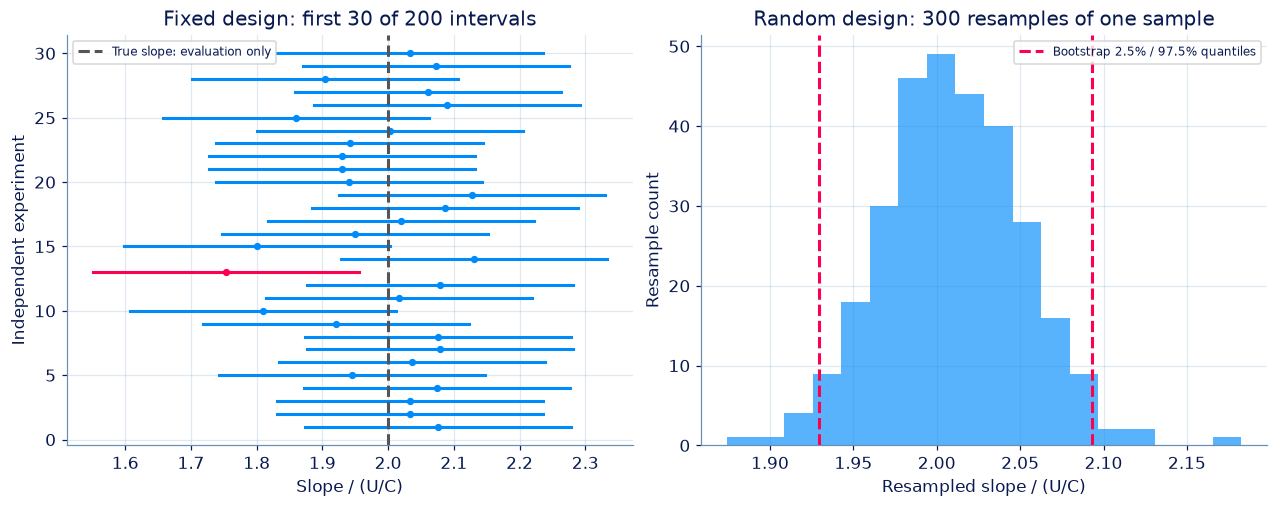

| 量 | 数值 |
| --- | --- |
| 固定设计覆盖频率 | 0.98 |
| 在理论 0.95 下的频率标准误 | 0.015411 |
| 自助区间下限 / U·C⁻¹ | 1.92964 |
| 自助区间上限 / U·C⁻¹ | 2.09311 |
| 秩亏重采样次数 | 0 |

In [4]:
seed=np.random.SeedSequence(6403)
repeat_seed,original_seed,bootstrap_seed=seed.spawn(3)
repeat_rng=np.random.default_rng(repeat_seed)
original_rng=np.random.default_rng(original_seed)
bootstrap_rng=np.random.default_rng(bootstrap_seed)
fixed_x=np.linspace(0,4,9)
intervals=[]
for _ in range(200):
    observed=1+2*fixed_x+repeat_rng.normal(0,sigma,len(fixed_x))
    intervals.append(slope_interval(fixed_x.tolist(),observed.tolist(),sigma,1.96))
intervals=np.asarray(intervals)
coverage=np.mean((intervals[:,1]<=2)&(2<=intervals[:,2]))
coverage_mcse=math.sqrt(0.95*0.05/200)
random_x=original_rng.uniform(0,4,40)
random_y=1+2*random_x+original_rng.normal(0,sigma,40)
boot_slopes,singular=pairs_bootstrap_slopes(random_x.tolist(),random_y.tolist(),300,bootstrap_rng)
boot_low,boot_high=np.quantile(boot_slopes,[0.025,0.975])
fig,axes=plt.subplots(1,2,figsize=(11.5,4.5))
first=intervals[:30]
hit=(first[:,1]<=2)&(2<=first[:,2])
for i,(estimate,low,high) in enumerate(first):
    axes[0].plot([low,high],[i+1,i+1],color=BLUE if hit[i] else PINK)
    axes[0].scatter([estimate],[i+1],color=BLUE if hit[i] else PINK,s=14)
axes[0].axvline(2,color=GRAY,ls='--',label='True slope: evaluation only')
axes[0].set(xlabel='Slope / (U/C)',ylabel='Independent experiment',title='Fixed design: first 30 of 200 intervals')
axes[0].legend(fontsize=8)
axes[1].hist(boot_slopes,bins=18,color=BLUE,alpha=0.65)
axes[1].axvline(boot_low,color=PINK,ls='--',label='Bootstrap 2.5% / 97.5% quantiles')
axes[1].axvline(boot_high,color=PINK,ls='--')
axes[1].set(xlabel='Resampled slope / (U/C)',ylabel='Resample count',title='Random design: 300 resamples of one sample')
axes[1].legend(fontsize=8)
plt.show()
display(Markdown(show_table(['量','数值'],[
    ('固定设计覆盖频率',coverage),('在理论 0.95 下的频率标准误',coverage_mcse),
    ('自助区间下限 / U·C⁻¹',boot_low),('自助区间上限 / U·C⁻¹',boot_high),('秩亏重采样次数',singular)])))

## 结果解释

左图只有前 30 个区间，蓝色横线包含真斜率，玫红横线未包含；覆盖频率则使用全部 200 次；即使规则理论覆盖约 95%，有限重复的频率也不必恰为 0.95，表中标准误衡量这个频率的 Monte Carlo 波动。右图的 300 条斜率来自同一份 40 人样本的重抽样。左图重新生成测量，右图重复利用现有样本；两者反映的重复过程不同。

### 独立核对与边界

In [5]:
# 无噪直线与代数标准误核对，不以生成真值参与估计。
estimate,low,high=slope_interval([0.,1.,2.],[1.,3.,5.],0.4,1.96)
assert estimate==2 and math.isclose(high-low,2*1.96*0.4/math.sqrt(2))
# 在均值浓度处，未来一次观测区间必宽于均值区间。
n=9
mean_halfwidth=1.96*sigma/math.sqrt(n)
future_halfwidth=1.96*sigma*math.sqrt(1+1/n)
assert future_halfwidth>mean_halfwidth
assert singular==0 and len(boot_slopes)==300
assert abs(coverage-0.95)<5*coverage_mcse
display(Markdown(show_table(['区间对象（x*=均值浓度）','半宽 / U'],[
    ('均值响应',mean_halfwidth),('未来一次读数',future_halfwidth)])))

| 区间对象（x*=均值浓度） | 半宽 / U |
| --- | --- |
| 均值响应 | 0.261333 |
| 未来一次读数 | 0.826409 |

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：已知测量噪声下的斜率区间

固定无误差xs，ys=β0+β1*xs+ε，ε独立N(0,sigma²)，sigma已知。给定正态临界值z，返回斜率（slope）估计和对称区间端点。

**函数与代码模板**

```python
def solve(
    xs: list[float],
    ys: list[float],
    sigma: float,
    z: float,
) -> tuple[float, float, float]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `xs` | `list[float]` | 已知且本题不含误差的实验输入（input）。 | U |
| `ys` | `list[float]` | 与xs对应的观测（observation）输出（output）。 | V |
| `sigma` | `float` | 已知观测噪声标准差（standard deviation）。 | V |
| `z` | `float` | 给定正态临界值，例如1.96约对应95%覆盖。 | 1 |

**返回值**

按以下顺序返回元组：(slope, lower, upper)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `slope` | `float` | 含截距OLS斜率。 | V/U |
| `lower` | `float` | 斜率区间下界。 | V/U |
| `upper` | `float` | 斜率区间上界。 | V/U |

**计算规则**

Sxx=Σ(xs−mean(xs))²；先求含截距OLS斜率β1，再返回β1±z*sigma/sqrt(Sxx)。这是参数（parameter）区间，不是未来个体读数的预测区间（prediction interval）。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 等长2—50点，绝对值≤100，Sxx≥1e−6；0<sigma≤10；0<z≤4。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| xs | 已知且本题不含误差的实验输入（input）。 | [0.0, 1.0, 2.0] | U |
| ys | 与xs对应的观测（observation）输出（output）。 | [1.0, 3.0, 5.0] | V |
| sigma | 已知观测噪声标准差（standard deviation）。 | 0.2 | V |
| z | 给定正态临界值，例如1.96约对应95%覆盖。 | 1.96 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
xs = [0.0, 1.0, 2.0]
ys = [1.0, 3.0, 5.0]
sigma = 0.2
z = 1.96

result = solve(xs, ys, sigma, z)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| slope | 含截距OLS斜率。 | 2 | V/U |
| lower | 斜率区间下界。 | ≈ 1.722814 | V/U |
| upper | 斜率区间上界。 | ≈ 2.277186 | V/U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (2.0,
                   1.7228141417748732,
                   2.2771858582251268)
```

**样例解释**

Sxx=2 U²，斜率2 V/U，区间约 [1.722814,2.277186] V/U；输入范围拉大时Sxx变大，在同一误差假设下区间可缩小。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：已知测量噪声下的斜率区间](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-slope-interval)

### 第 2 题 · 单项选择题：95%覆盖率指谁变化

固定真实参数（parameter）与设计，重复生成独立观测（observation）并每次构造同一种95%置信区间（confidence interval）。哪项正确？

- **A.** 参数区间直接就是下一次读数区间。
- **B.** 在所列模型（model）条件下，这个构造长期约95%覆盖固定参数。
- **C.** 真实参数每次以95%概率（probability）重新抽入一个固定区间。
- **D.** 只要区间窄就涵盖所有结构误差。

[作答：95%覆盖率指谁变化](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-interval-meaning)

### 第 3 题 · 多项选择题：未知方差时为什么需要额外条件

固定设计（fixed design）、独立同方差（homoscedasticity）高斯误差（Gaussian error），含p个可识别系数，N>p。哪些正确？

- **A.** 常用残差（residual）方差（variance）估计为SSE/(N−p)。
- **B.** 把估计标准差（standard deviation）直接代入1.96即可保证任何小样本精确95%覆盖。
- **C.** 精确高斯线性模型（model）下，使用t分布（distribution）临界值反映方差估计的不确定性。
- **D.** N=p且恰好插值时仍可由0/0可靠估计方差。

[作答：未知方差时为什么需要额外条件](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-unknown-variance)

### 第 4 题 · 多项选择题：应该重采样什么单位

计划用自助法评估估计波动。哪些设计和解释合理？

- **A.** 时间相关的一条轨迹（trajectory）可任意打散为独立点而不改变目标。
- **B.** 固定设计（fixed design）回归的残差（residual）自助法须说明误差模型（model），不能与随机设计（random design）对自助法混用。
- **C.** 自助区间没有自动囊括未建模机制偏差。
- **D.** 独立随机设计观测（observation）对可成对重采样（resampling），声明重采样次数和区间方法。

[作答：应该重采样什么单位](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-bootstrap-unit)

**进一步阅读**

[NIST：最小二乘与残差尺度](https://www.itl.nist.gov/div898/handbook/pmd/section4/pmd431.htm)和[区间类型及解释](https://www.itl.nist.gov/div898/handbook/pmd/section5/pmd512.htm)。本节从斜率的线性组合推导方差，重采样循环用于理解经验分布近似，不代替对其覆盖条件的分析。